In [15]:
import pandas as pd
import numpy as np

# 1. Load your uploaded dataset
df = pd.read_excel("Aemiro.xlsx") # Corrected filename from "Aemiro.xlsx - geofinal (1).csv"

# 2. Define the Target Variable (Adaptation Zone) based on Altitude thresholds
# Kolla (Lowland/Warm): < 1500m -> Label 0
# Weyna Dega (Midland/Temperate): 1500m - 2300m -> Label 1
# Dega (Highland/Cool): > 2300m -> Label 2
def assign_zone(altitude):
    if altitude < 1500:
        return 0  # Kolla
    elif 1500 <= altitude <= 2300:
        return 1  # Weyna Dega
    else:
        return 2  # Dega

df['adaptation_zone'] = df['Altitude'].apply(assign_zone)

# 3. Select ONLY the highly valuable features for XGBoost / LightGBM
features_and_target = [
    'Altitude',
    'ph_ho_60cm',
    'bio1_1970_2000',
    'bio4_1970_2000',
    'bio12_1970_2000',
    'bio15_1970_2000',
    'adaptation_zone'
]

clean_ml_dataset = df[features_and_target].dropna()

# 4. Save the optimized dataset
clean_ml_dataset.to_csv("climate_adaptability_dataset.csv", index=False)
print("Success! Your ML-ready dataset 'climate_adaptability_dataset.csv' has been generated and saved.")

Success! Your ML-ready dataset 'climate_adaptability_dataset.csv' has been generated and saved.


In [16]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [18]:
#Load Data
df = pd.read_csv("climate_adaptability_dataset.csv")

print("Dataset shape:", df.shape)
print("\nClass distribution:\n", df["adaptation_zone"].value_counts())
print("\nMissing values:\n", df.isnull().sum())

Dataset shape: (2065, 7)

Class distribution:
 adaptation_zone
1    1332
2     660
0      73
Name: count, dtype: int64

Missing values:
 Altitude           0
ph_ho_60cm         0
bio1_1970_2000     0
bio4_1970_2000     0
bio12_1970_2000    0
bio15_1970_2000    0
adaptation_zone    0
dtype: int64


In [21]:
# Map target labels
# Ethiopian climate zones:
#   2→ Dega       (highland, cool, >2300m)
#   1 → Weina Dega (mid-altitude, temperate, 1500–2300m)
#   0 →Kolla  (lowland, hot, <1500m)
zone_map = {0: "kolla", 1: "Weina Dega", 2: "dega"}
df["zone_label"] = df["adaptation_zone"].map(zone_map)

In [22]:
#Features & Target
FEATURES = [
    "Altitude",        # Elevation in metres
    "ph_ho_60cm",      # Soil pH at 0–60 cm depth
    "bio1_1970_2000",  # Mean Annual Temperature (°C × 10 in WorldClim, here as °C)
    "bio4_1970_2000",  # Temperature Seasonality (std dev × 100)
    "bio12_1970_2000", # Annual Precipitation (mm)
    "bio15_1970_2000", # Precipitation Seasonality (CV)
]

X = df[FEATURES]
y = df["adaptation_zone"]  # already encoded as 0,1,2

In [23]:
#Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]} | Test: {X_test.shape[0]}")


Train: 1652 | Test: 413


In [24]:
# ── 5. XGBoost Model ─────────────────────────────────────────────────────────
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50,
)

[0]	validation_0-mlogloss:0.72540
[50]	validation_0-mlogloss:0.09255
[100]	validation_0-mlogloss:0.04021


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:28:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[150]	validation_0-mlogloss:0.03879
[200]	validation_0-mlogloss:0.04354
[250]	validation_0-mlogloss:0.04251
[299]	validation_0-mlogloss:0.04187


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)


Test Accuracy: 0.9927

Classification Report:
              precision    recall  f1-score   support

        Dega       1.00      1.00      1.00        15
       Kolla       0.99      1.00      0.99       266
  Weina Dega       1.00      0.98      0.99       132

    accuracy                           0.99       413
   macro avg       1.00      0.99      0.99       413
weighted avg       0.99      0.99      0.99       413

Confusion matrix saved → confusion_matrix.png


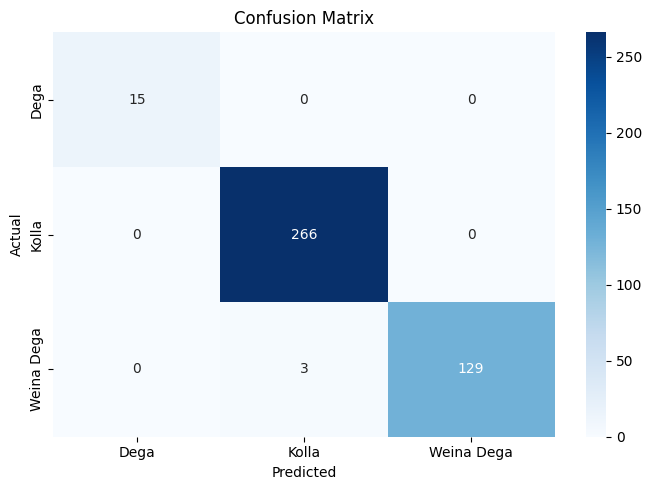

In [25]:
#Evaluation ─────────────────────────────────────────────────────────────
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Dega", "Kolla", "Weina Dega"]))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Dega", "Kolla", "Weina Dega"],
    yticklabels=["Dega", "Kolla", "Weina Dega"],
)
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
print("Confusion matrix saved → confusion_matrix.png")



Feature importance saved → feature_importance.png


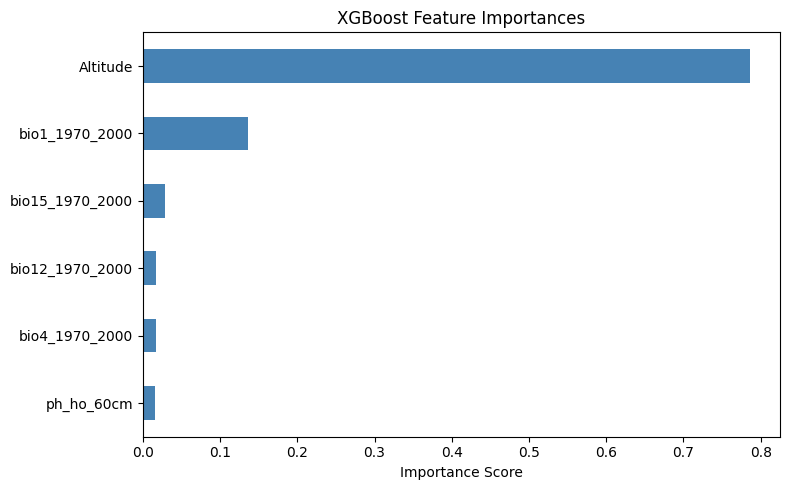

In [ ]:
# Feature importance plot
fig, ax = plt.subplots(figsize=(8, 5))
importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
importances.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("XGBoost Feature Importances")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
print("Feature importance saved → feature_importance.png")

In [26]:
#7,Save Model & Metadata ──────────────────────────────────────────────────
os.makedirs("model", exist_ok=True)
joblib.dump(model, "model/xgb_climate_model.pkl")
joblib.dump(FEATURES, "model/features.pkl")
print("✅ Model saved!")

✅ Model saved!


In [27]:
# downloadfiles
from google.colab import files
files.download("model/xgb_climate_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
#download files
from google.colab import files
files.download("model/features.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>